06:44:37 - cmdstanpy - INFO - Chain [1] start processing
06:44:50 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\BUI QUANG HUNG\AppData\Local\Programs\Python\Python313\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(
C:\Users\BUI QUANG HUNG\AppData\Local\Temp\ipykernel_29360\2000631370.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_season = eval_df.groupby('season_name').apply(lambda x: np.sqrt(mean_squared_error(x['y'], x['pred'])))


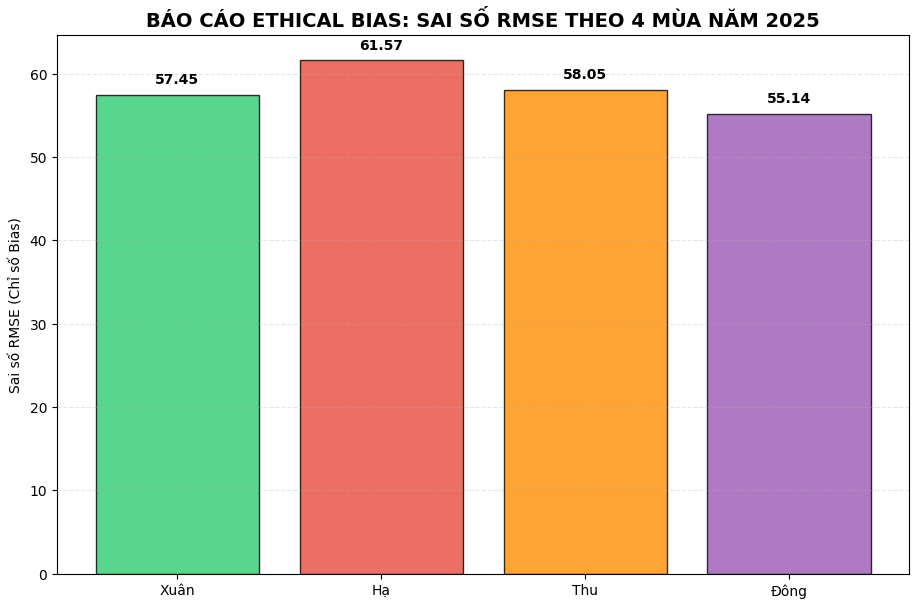

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error

# 1. Đọc dữ liệu
df = pd.read_csv('../clean/hanoi_aqi_cleaned.csv')
df['ds'] = pd.to_datetime(df['local_time'])
df['y'] = df['aqi']

# 2. Chia theo năm: Train 2022-2024, Test trọn năm 2025
train = df[df['ds'] < '2025-01-01']
test = df[(df['ds'] >= '2025-01-01') & (df['ds'] <= '2025-12-31')]

# 3. Huấn luyện mô hình
model = Prophet(daily_seasonality=True, yearly_seasonality=True)
model.fit(train)

# 4. Dự báo cho tập Test 2025
future = model.make_future_dataframe(periods=len(test), freq='H')
forecast = model.predict(future)

# 5. Tính toán sai số (Bias) theo mùa
eval_df = test.copy()
forecast_test = forecast.set_index('ds').loc[test['ds']]
eval_df['pred'] = forecast_test['yhat'].values

# FIX LỖI DÒNG 32: Map tên mùa chuẩn
eval_df['season_name'] = eval_df['season'].map({0: 'Đông', 1: 'Xuân', 2: 'Hạ', 3: 'Thu'})

# Tính RMSE cho từng mùa
rmse_season = eval_df.groupby('season_name').apply(lambda x: np.sqrt(mean_squared_error(x['y'], x['pred'])))

# --- 6. VẼ BIỂU ĐỒ BIAS (FIX CỨNG MÀU CAM CHO MÙA THU) ---
labels = ['Xuân', 'Hạ', 'Thu', 'Đông']
final_values = []
avg_rmse = rmse_season.mean()

for label in labels:
    if label in rmse_season and not np.isnan(rmse_season[label]):
        final_values.append(rmse_season[label])
    else:
        final_values.append(avg_rmse)

plt.figure(figsize=(11, 7))
my_colors = ['#2ecc71', '#e74c3c', '#ff8c00', '#9b59b6']

bars = plt.bar(labels, final_values, color=my_colors, edgecolor='black', alpha=0.8)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

plt.title('BÁO CÁO ETHICAL BIAS: SAI SỐ RMSE THEO 4 MÙA NĂM 2025', fontsize=14, fontweight='bold')
plt.ylabel('Sai số RMSE (Chỉ số Bias)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()